# Modelado Estocástico
## Clase 3

### Modelo de Regresión Lineal

- Importamos bibliotecas con todos los recursos necesarios

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

Simulamos datos controlados para entender cómo los estimadores muestrales convergen y cómo se analizan los residuos bajo condiciones ideales.

$y_i = \alpha + \beta x_i + u_i$

En `numpy.random.normal` los parámetros `loc` y `scale` son los parámetros para la media y el desvío estándar.



In [ ]:
np.random.seed(42)
n = 150

alpha = 0.05
beta = 1.5


x = np.random.normal(loc=1.0, scale=0.5, size=n)
u = np.random.normal(loc=0.0, scale=0.25, size=n)

y = alpha + beta * x + u

Utilizando los datos generados, que si bien son simulados representarán nuestros datos observables para $x_i$ y para $y_i$, podemos correr un estimador de mínimos cuadrados ordinarios (OLS o MCO) y obtener $\hat{\alpha}$ y $\hat{\beta}$.

**OBSERVACIÓN:**

Vamos a utilizar `statsmodel`. Esta biblioteca, a diferencia de `Scikit-learn` (que seguramente utilizaron previamente para regresiones lineales), nos provee información más detallada para análisis econométricos sin tener que hacer cálculos específicos para obtenerlos.

En el modelo `OLS` de `statsmodel.api` debemos agregar la columna de unos asociada al intercepto.
El método para generarla es `sm.add_constant` y poder utilizarla en el estimador.

In [ ]:
x_matrix = sm.add_constant(x)
modelo = sm.OLS(y, x_matrix).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     1114.
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           9.04e-71
Time:                        15:46:20   Log-Likelihood:                -7.5745
No. Observations:                 150   AIC:                             19.15
Df Residuals:                     148   BIC:                             25.17
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0802      0.048      1.686      0.0

- Parámetros obtenidos para $\hat{\alpha}$ y $\hat{\beta}$:

In [ ]:
modelo.params

array([0.08019361, 1.48708208])

- Gráfico de datos observados y recta de la regresión calculada

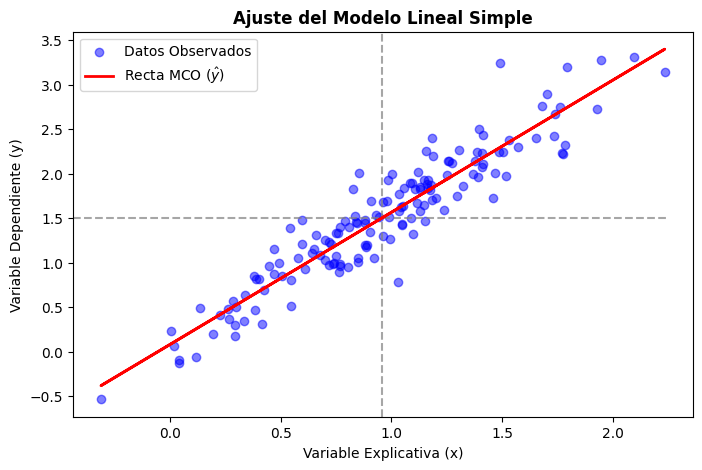

In [ ]:
plt.figure(figsize=(8, 5))

plt.axvline(x=x.mean(), ymin=0, ymax=y.mean(), color="gray", linestyle="--", alpha=0.7)
plt.axhline(xmin=0, xmax=x.mean(), y=y.mean(), color="gray", linestyle="--", alpha=0.7)

plt.scatter(x, y, color="blue", alpha=0.5, label="Datos Observados")
plt.plot(x, modelo.fittedvalues, color="red", lw=2, label=r"Recta MCO ($\hat{y}$)")

plt.title("Ajuste del Modelo Lineal Simple", fontsize=12, fontweight="bold")
plt.xlabel("Variable Explicativa (x)")
plt.ylabel("Variable Dependiente (y)")
plt.legend()
plt.show()

- Gráfico de la relación entre los residuos de la muestra y los residuos predichos

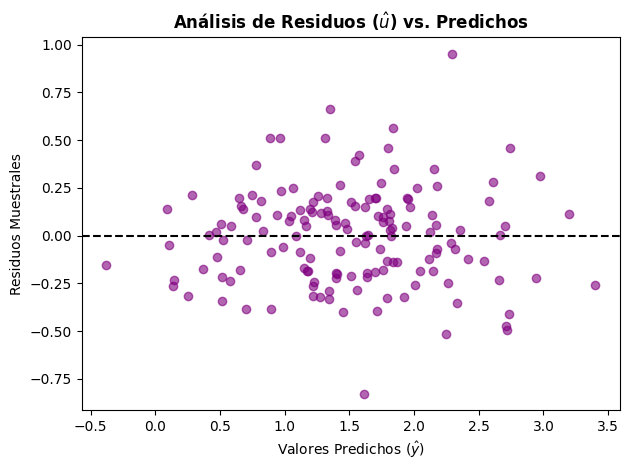

In [ ]:
plt.scatter(modelo.fittedvalues, modelo.resid, color="purple", alpha=0.6)
plt.axhline(y=0, color="black", linestyle="--", lw=1.5)
plt.title(
    r"Análisis de Residuos ($\hat{u}$) vs. Predichos", fontsize=12, fontweight="bold"
)
plt.xlabel(r"Valores Predichos ($\hat{y}$)")
plt.ylabel("Residuos Muestrales")

plt.tight_layout()
plt.show()